# MLP Test Evaluation

The one and only time this project's held-out test set gets touched (`mlp_classifier.evaluate_test_metrics`), after training/tuning is fully finished. Every other notebook and every ablation in this project (`mlp_ablations.ipynb`) evaluated on val only, exactly so this check stays meaningful: a real, blind estimate of the baseline's generalization, not a number that's already been peeked at and used to pick a model.

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent / "scripts"))
from build_points_table import build_and_save_points_table
from taxonomy_separability import add_relative_features
from mlp_classifier import apply_mlp_class_groups, run_training, evaluate_test_metrics

df = build_and_save_points_table()
df = add_relative_features(df)
df = apply_mlp_class_groups(df)


/home/bruno/radar_machine_learning_ws/results/data/points_table.parquet already covers exactly the requested sequences, skipping build


## Load baseline (cached)

`run_training` loads the cached model/history if this exact config was already run, it does not retrain.

/home/bruno/radar_machine_learning_ws/results/mlp/mlp_training_history.json already matches this config, loading cached model + history


Saved /home/bruno/radar_machine_learning_ws/results/mlp/mlp_training_curves.png


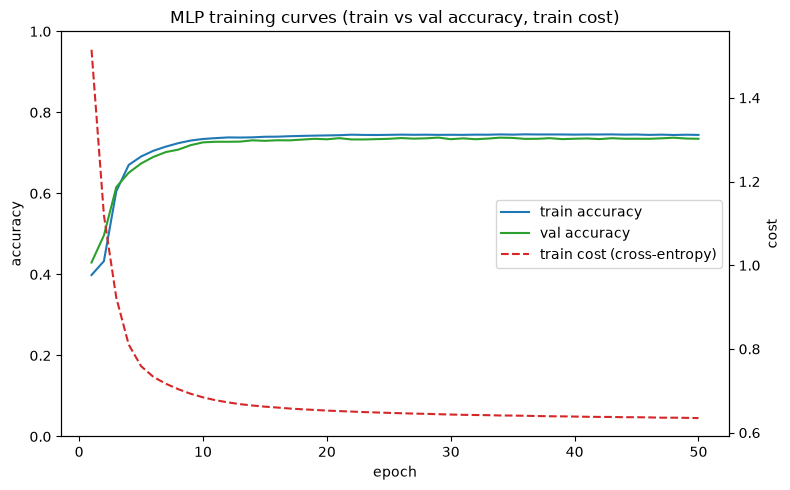

In [2]:
# uses cached model + history if EPOCHS/BATCH_SIZE/LEARNING_RATE match a prior run - no retraining
model, history, X_test, y_test = run_training(df)


## Test metrics

Per-class precision/recall/f1 + confusion matrix on test, computed from the cached model only, never retrains.

Saved /home/bruno/radar_machine_learning_ws/results/mlp/mlp_test_metrics.json
per-class precision/recall/f1 (test):
                  precision  recall     f1  support
car                   0.943   0.821  0.877    29958
large_vehicle         0.740   0.793  0.766     6103
two_wheeler           0.511   0.637  0.567     4879
pedestrian            0.533   0.928  0.677    11363
pedestrian_group      0.775   0.500  0.608    17420
Saved /home/bruno/radar_machine_learning_ws/results/mlp/mlp_test_confusion_matrix.png


Saved /home/bruno/radar_machine_learning_ws/results/mlp/mlp_test_precision_recall_f1.png


,precision,recall,f1,support
car,0.942776,0.820515,0.877407,29958
large_vehicle,0.739835,0.793053,0.765520,6103
two_wheeler,0.510932,0.637016,0.567050,4879
pedestrian,0.532788,0.928100,0.676959,11363
pedestrian_group,0.775265,0.499828,0.607797,17420


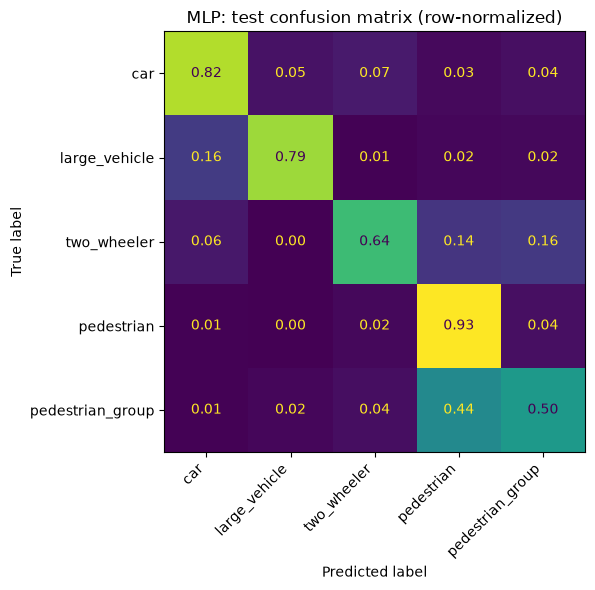

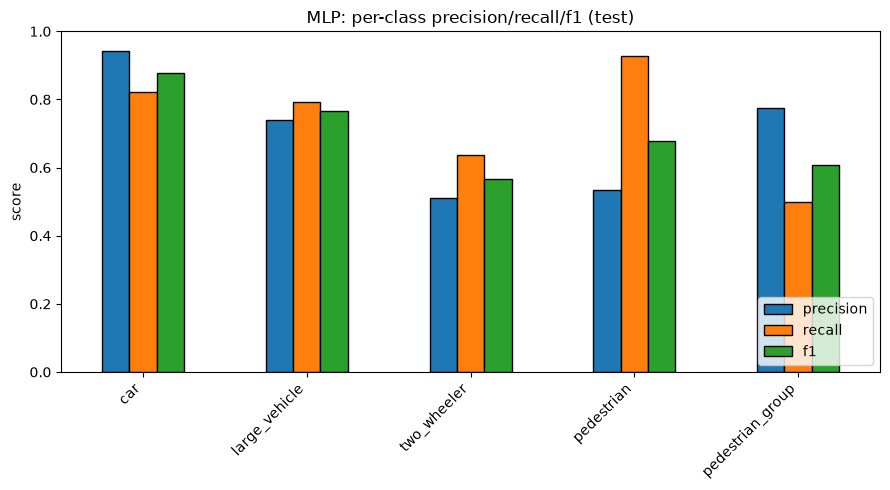

In [3]:
metrics_df, cm_fig, bar_fig = evaluate_test_metrics(df)
metrics_df


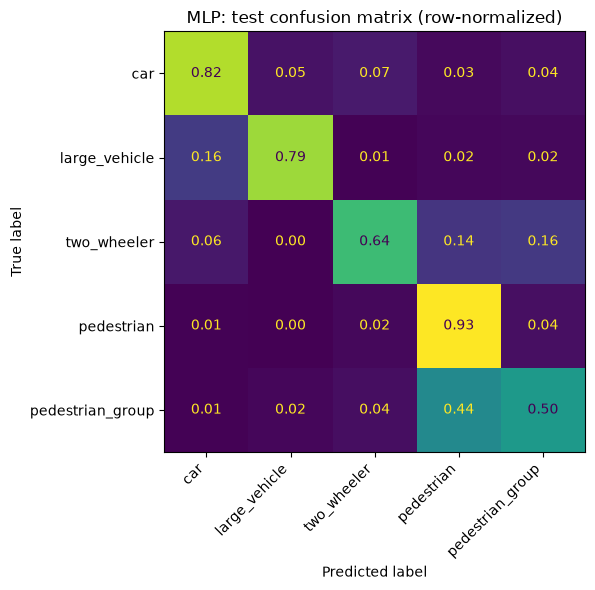

In [4]:
cm_fig

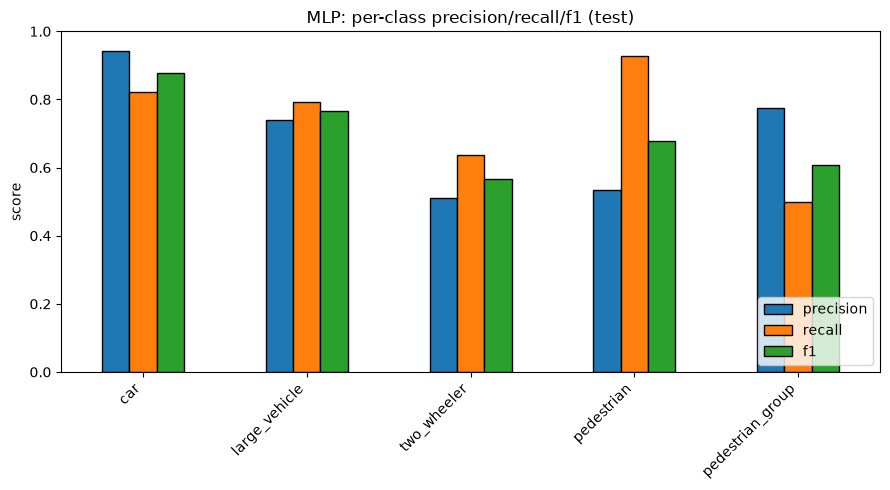

In [5]:
bar_fig

## Test vs. val

Side by side against the standing val numbers (`results/mlp/mlp_val_metrics.json`), no retraining, both computed from the same cached baseline model.

In [6]:
import pandas as pd

val_metrics = pd.read_json("../results/mlp/mlp_val_metrics.json", orient="index")
comparison = pd.DataFrame({
    "val_f1": val_metrics["f1"], "test_f1": metrics_df["f1"],
    "val_recall": val_metrics["recall"], "test_recall": metrics_df["recall"],
})
comparison.loc["macro_avg"] = comparison.mean()
comparison.round(3)


,val_f1,test_f1,val_recall,test_recall
car,0.854,0.877,0.784,0.821
large_vehicle,0.756,0.766,0.797,0.793
two_wheeler,0.508,0.567,0.545,0.637
pedestrian,0.682,0.677,0.944,0.928
pedestrian_group,0.632,0.608,0.544,0.500
macro_avg,0.686,0.699,0.723,0.736
